# Conditional Probability

This notebook explains **conditional probability**, which is the probability of an event occurring given that another event has already occurred. It is a fundamental concept for understanding how events influence one another.


## What is Conditional Probability?

The **conditional probability** of an event A given an event B, written as $P(A|B)$, is the probability that event A will occur, given that event B has already occurred.

This concept effectively reduces our sample space. Instead of considering all possible outcomes, we "zoom in" on the outcomes where B is true and calculate the probability of A within that new, smaller world.


## Formula for Conditional Probability

The conditional probability $P(A|B)$ is calculated as the ratio of the joint probability of A and B to the marginal probability of B.

$P(A|B) = \frac{P(A \cap B)}{P(B)}$

**Intuition:**
- The numerator, $P(A \cap B)$, is the probability of the case where both the event we care about (A) and the condition we know is true (B) happen.
- The denominator, $P(B)$, rescales the probability from the original sample space to the new sample space defined by B.


## Example: Colored Shapes

Let's use our colored shapes example to make this concrete.
- **X (Color):** {Red, Green, Blue}
- **Y (Shape):** {Sphere, Cube}

The counts are:


In [ ]:
import pandas as pd

# Counts table
counts = pd.DataFrame(
    [[18, 12, 30],
     [16, 20, 4]],
    index=['Shape=S', 'Shape=C'],
    columns=['Color=R', 'Color=G', 'Color=B']
)

# Joint probability table
joint_prob = counts / counts.values.sum()

# Marginal probability of Shape (P(Y))
marginal_shape = joint_prob.sum(axis=1)

# Conditional probability P(Color | Shape) = P(X | Y)
# We get this by dividing each row of the joint table by the corresponding marginal probability of that row
cond_prob_x_given_y = joint_prob.divide(marginal_shape, axis=0)

print("--- Counts Table ---")
display(counts)

print("\\n--- Joint Probability P(X,Y) ---")
display(joint_prob)

print("\\n--- Marginal Probability P(Y) ---")
display(marginal_shape.to_frame('P(Shape)'))

print("\\n--- Conditional Probability P(X|Y) ---")
display(cond_prob_x_given_y)

# Example calculation
p_r_given_s = cond_prob_x_given_y.loc['Shape=S', 'Color=R']
print(f"\\nExample: P(Color=R | Shape=S) = {p_r_given_s:.2f}")
print(f"This is calculated as P(Color=R, Shape=S) / P(Shape=S) = {joint_prob.loc['Shape=S', 'Color=R']:.2f} / {marginal_shape['Shape=S']:.2f} = {p_r_given_s:.2f}")


## The Conditional Probability Distribution

The **conditional probability distribution** of $X$ given $Y=y_j$ is the set of all conditional probabilities $P(X=x_i | Y=y_j)$ for all possible values of $X$.

A key property is that for a fixed condition (e.g., $Y=y_j$), the sum of all conditional probabilities over $X$ must equal 1.

From our table, the conditional distribution of `Color` given `Shape=S` is:
- $P(\text{Color=R} | \text{Shape=S}) = 0.30$
- $P(\text{Color=G} | \text{Shape=S}) = 0.20$
- $P(\text{Color=B} | \text{Shape=S}) = 0.50$

Sum: $0.30 + 0.20 + 0.50 = 1.0$. This shows that given we have a Sphere, it must be one of these three colors.


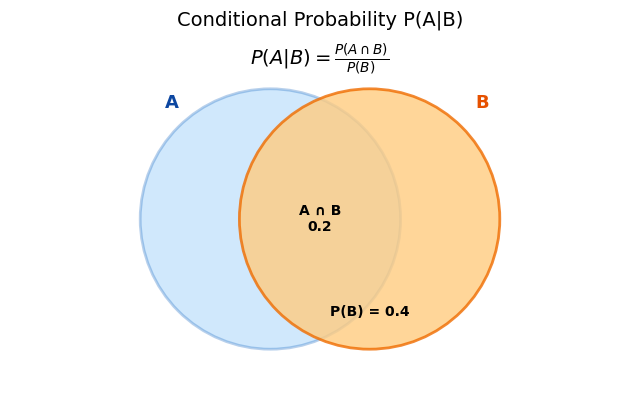

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, PathPatch
from matplotlib.path import Path

fig, ax = plt.subplots(figsize=(8, 5))

# --- Define probabilities and circles ---
p_a_only = 0.3
p_b_only = 0.2
p_intersection = 0.2
p_a = p_a_only + p_intersection
p_b = p_b_only + p_intersection

circle_a = Circle((4.0, 3.0), 2.0, facecolor='#64b5f6', alpha=0.5)
circle_b = Circle((6.0, 3.0), 2.0, facecolor='#ffcc80', alpha=0.7)

# --- Draw the diagram ---
ax.add_patch(Rectangle((0, 0), 10, 6, fill=False, linewidth=2, edgecolor='black'))
ax.text(0.2, 5.7, 'S', fontsize=12, fontweight='bold')

ax.add_patch(circle_a)
ax.add_patch(circle_b)

# --- Highlight the intersection ---
# Create a path for the intersection of the two circles
path_a = circle_a.get_path().transformed(circle_a.get_patch_transform())
path_b = circle_b.get_path().transformed(circle_b.get_patch_transform())
intersection_path = Path.make_compound_path(path_a, path_b)
patch = PathPatch(intersection_path, facecolor='red', alpha=0.6)
ax.add_patch(patch)


# --- Add annotations ---
ax.text(5.0, 3.0, f'$A \\cap B$', ha='center', va='center', fontsize=11, color='white', weight='bold')
ax.text(6.0, 0.8, f'New Sample Space: B', ha='center', fontsize=12, weight='bold', color='#e65100')
ax.text(2.5, 5.0, 'A', fontsize=14, weight='bold', color='#0d47a1')

# Formula
ax.set_title('Visualizing Conditional Probability $P(A|B)$', fontsize=14)
ax.text(5, 0.2, r'$P(A|B) = \frac{P(A \cap B)}{P(B)} = \frac{0.2}{0.4} = 0.5$', ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 6.5)
ax.set_aspect('equal')
ax.axis('off')
plt.show()


## Visualizing Conditional Probability

The Venn diagram below illustrates the idea of reducing the sample space.

When we ask for $P(A|B)$, we are no longer considering the entire sample space $S$. We are "zooming in" to the world where B has happened. Circle B becomes our new universe.

Within this new universe (the orange circle), the part of A that can still happen is the intersection ($A \cap B$).

Therefore, the conditional probability is the ratio of the size of the intersection to the size of our new universe, B.

$P(A|B) = \frac{\text{Area of } (A \cap B)}{\text{Area of } B}$


## Summary

- **Conditional Probability** $P(A|B)$ is the probability of A happening, given that B has already happened.
- It is calculated by dividing the joint probability of both events by the probability of the condition: $P(A|B) = P(A \cap B) / P(B)$.
- This can be thought of as reducing the sample space to the outcomes where B is true.
- The sum of conditional probabilities of a variable, given a fixed condition, must equal 1.
